# A/B Test Analysis: Fee & Exchange Rate Transparency

**Business question:** when a user sends an international transfer, does showing the full breakdown (amount sent, exchange rate applied, fee, final amount received) change completion behavior, compared to showing only the final amount the recipient gets?

**Experiment setup**
- **Control (A):** only the final amount received is shown
- **Treatment (B):** full breakdown is shown (amount sent, exchange rate, fee, final amount)
- **Primary metric:** `transfer_completed` (1 if the user finishes the transfer, 0 if they abandon it)
- **Guardrail metrics:** `satisfaction_score` (0-10, post-transaction survey) and `repeated_within_30d` (did the user send another transfer within 30 days)
- **Randomization:** 50/50 split, ~5,000 transfers per group, across small (under $200) and large (over $200) transfers
- **Duration:** 4 weeks

**Hypotheses**
- H0: the completion rate is the same in control and treatment
- H1: the completion rate is different between control and treatment

Two-sided test, alpha = 0.05, decided before looking at results. I'm also pre-registering that I'll look at the effect broken down by transfer size, since there's a real business reason to expect the effect could differ for a $30 transfer versus a $1,000 transfer (the fee matters a lot more, in relative terms, on a small transfer).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## 1. Load and inspect the data

In [2]:
df = pd.read_csv("fee_transparency_ab_test_data.csv", parse_dates=["sent_at"])
print(df.shape)
df.head()


(10000, 9)


,transfer_id,group,amount_tier,amount_sent_usd,sent_at,destination_country,transfer_completed,satisfaction_score,repeated_within_30d
0,708756,treatment,large,1262.04,2026-04-06 00:08:00,Mexico,1,6.9,0.0
1,705147,treatment,small,62.50,2026-04-06 00:25:00,Peru,1,5.6,1.0
2,708100,treatment,large,680.72,2026-04-06 00:25:00,Mexico,1,8.3,0.0
3,707069,treatment,small,70.10,2026-04-06 00:29:00,Peru,1,9.4,1.0
4,702245,control,small,179.05,2026-04-06 00:31:00,Republica Dominicana,1,5.4,1.0


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   transfer_id          10000 non-null  int64         
 1   group                10000 non-null  str           
 2   amount_tier          10000 non-null  str           
 3   amount_sent_usd      10000 non-null  float64       
 4   sent_at              10000 non-null  datetime64[us]
 5   destination_country  10000 non-null  str           
 6   transfer_completed   10000 non-null  int64         
 7   satisfaction_score   7926 non-null   float64       
 8   repeated_within_30d  7926 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(2), str(3)
memory usage: 703.3 KB


In [4]:
df.isna().sum()


transfer_id               0
group                     0
amount_tier               0
amount_sent_usd           0
sent_at                   0
destination_country       0
transfer_completed        0
satisfaction_score     2074
repeated_within_30d    2074
dtype: int64

`satisfaction_score` and `repeated_within_30d` are only populated for completed transfers, which makes sense: there's no post-transaction survey or repeat behavior to measure if the transfer never happened.

## 2. Sanity checks before trusting the results

In [5]:
group_counts = df["group"].value_counts()
group_counts


group
treatment    5000
control      5000
Name: count, dtype: int64

In [6]:
observed = group_counts.values
expected = [df.shape[0] / 2, df.shape[0] / 2]
chi2, p_srm = stats.chisquare(f_obs=observed, f_exp=expected)
print(f"Chi-square = {chi2:.4f}, p-value = {p_srm:.4f}")
print("Group split looks consistent with 50/50." if p_srm >= 0.01 else "Warning: possible SRM.")


Chi-square = 0.0000, p-value = 1.0000
Group split looks consistent with 50/50.


In [7]:
print("Duplicate transfer_ids:", df["transfer_id"].duplicated().sum())
print("Date range:", df["sent_at"].min(), "to", df["sent_at"].max())
print("\nAmount tier split (should also be balanced across groups):")
print(pd.crosstab(df["group"], df["amount_tier"]))


Duplicate transfer_ids: 0
Date range: 2026-04-06 00:08:00 to 2026-05-03 23:51:00

Amount tier split (should also be balanced across groups):
amount_tier  large  small
group                    
control       2500   2500
treatment     2500   2500


## 3. Overall completion rate: what the topline number says

If I stopped here, this is the number I'd report to the team.

In [8]:
overall = df.groupby("group")["transfer_completed"].agg(users="count", completed="sum", conversion_rate="mean")
overall["conversion_rate"] = (overall["conversion_rate"] * 100).round(2)
overall


,users,completed,conversion_rate
group,,,
control,5000,3946,78.92
treatment,5000,3980,79.60


In [9]:
completed = df.groupby("group")["transfer_completed"].sum()
nobs = df.groupby("group")["transfer_completed"].count()

z_stat, p_value = proportions_ztest(
    count=[completed["treatment"], completed["control"]],
    nobs=[nobs["treatment"], nobs["control"]],
    alternative="two-sided",
)
print(f"z-statistic = {z_stat:.4f}")
print(f"p-value = {p_value:.4f}")


z-statistic = 0.8386
p-value = 0.4017


**Reading this:** the overall difference is small (well under 1 point) and the p-value is well above 0.05. Taken at face value, this says "the treatment made no difference, don't ship it."

Before accepting that conclusion, I want to check whether that flat topline number is hiding something, since I already had a hypothesis that the effect might depend on transfer size.

## 4. Segmenting by transfer size: the real story

This is the part that matters. I'm splitting the sample by `amount_tier` (small: under $200, large: $200 and up) and repeating the same comparison inside each segment.

In [10]:
segment = df.groupby(["group", "amount_tier"])["transfer_completed"].agg(users="count", conversion_rate="mean")
segment["conversion_rate"] = (segment["conversion_rate"] * 100).round(2)
segment


users  conversion_rate
group     amount_tier                        
control   large         2500            75.36
          small         2500            82.48
treatment large         2500            80.64
          small         2500            78.56

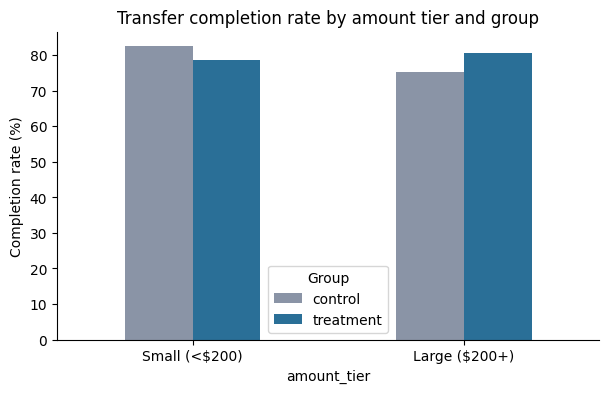

In [11]:
fig, ax = plt.subplots()
plot_data = df.groupby(["amount_tier", "group"])["transfer_completed"].mean().unstack() * 100
plot_data = plot_data.loc[["small", "large"]]
plot_data.plot(kind="bar", ax=ax, color=["#8a94a6", "#2a6f97"])
ax.set_ylabel("Completion rate (%)")
ax.set_title("Transfer completion rate by amount tier and group")
ax.set_xticklabels(["Small (<$200)", "Large ($200+)"], rotation=0)
ax.legend(title="Group")
plt.show()


In [12]:
for tier in ["small", "large"]:
    sub = df[df["amount_tier"] == tier]
    completed_t = sub.groupby("group")["transfer_completed"].sum()
    nobs_t = sub.groupby("group")["transfer_completed"].count()
    z_stat, p_value = proportions_ztest(
        count=[completed_t["treatment"], completed_t["control"]],
        nobs=[nobs_t["treatment"], nobs_t["control"]],
        alternative="two-sided",
    )
    diff = sub.groupby("group")["transfer_completed"].mean()
    print(f"--- {tier.upper()} transfers ---")
    print(f"Control: {diff['control']*100:.2f}%  |  Treatment: {diff['treatment']*100:.2f}%")
    print(f"Difference: {(diff['treatment']-diff['control'])*100:+.2f} pp")
    print(f"z = {z_stat:.3f}, p-value = {p_value:.4f}\n")


--- SMALL transfers ---
Control: 82.48%  |  Treatment: 78.56%
Difference: -3.92 pp
z = -3.499, p-value = 0.0005

--- LARGE transfers ---
Control: 75.36%  |  Treatment: 80.64%
Difference: +5.28 pp
z = 4.506, p-value = 0.0000



**This is a Simpson's paradox pattern:** the aggregate result looked flat, but it was actually two real, statistically significant effects in opposite directions cancelling each other out.

- For **small transfers**, showing the fee breakdown makes people less likely to finish. Seeing the fee explicitly, on a transfer where it's a bigger share of the total, seems to trigger hesitation.
- For **large transfers**, showing the breakdown makes people *more* likely to finish. My read: on a bigger transfer, the transparency builds trust and reduces the "is this a hidden fee trap" concern that can cause abandonment.

If I had only looked at the topline number, I would have concluded "no effect" and moved on, which would have been the wrong call.

## 5. Guardrail metrics: satisfaction and repeat usage

Completion rate is not the only thing that matters here. I also want to check the metrics that protect the business from optimizing the wrong thing: does transparency change how satisfied people are, and whether they come back.

In [13]:
sat_control = df.loc[(df["group"] == "control") & (df["transfer_completed"] == 1), "satisfaction_score"]
sat_treatment = df.loc[(df["group"] == "treatment") & (df["transfer_completed"] == 1), "satisfaction_score"]

print(f"Control satisfaction:   {sat_control.mean():.2f} (n={len(sat_control)})")
print(f"Treatment satisfaction: {sat_treatment.mean():.2f} (n={len(sat_treatment)})")

t_stat, p_value_sat = stats.ttest_ind(sat_treatment, sat_control, equal_var=False)
print(f"\nt-statistic = {t_stat:.4f}, p-value = {p_value_sat:.6f}")


Control satisfaction:   7.00 (n=3946)
Treatment satisfaction: 7.63 (n=3980)

t-statistic = 19.9865, p-value = 0.000000


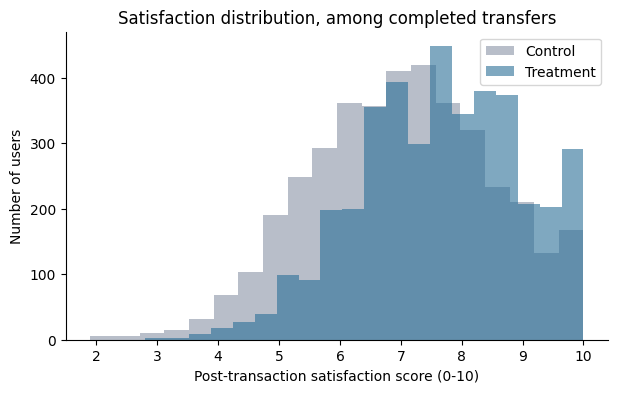

In [14]:
fig, ax = plt.subplots()
ax.hist(sat_control, bins=20, alpha=0.6, label="Control", color="#8a94a6")
ax.hist(sat_treatment, bins=20, alpha=0.6, label="Treatment", color="#2a6f97")
ax.set_xlabel("Post-transaction satisfaction score (0-10)")
ax.set_ylabel("Number of users")
ax.set_title("Satisfaction distribution, among completed transfers")
ax.legend()
plt.show()


In [15]:
rep_control = df.loc[(df["group"] == "control") & (df["transfer_completed"] == 1), "repeated_within_30d"]
rep_treatment = df.loc[(df["group"] == "treatment") & (df["transfer_completed"] == 1), "repeated_within_30d"]

z_stat, p_value_rep = proportions_ztest(
    count=[rep_treatment.sum(), rep_control.sum()],
    nobs=[len(rep_treatment), len(rep_control)],
    alternative="two-sided",
)
print(f"Control repeat rate (30d):   {rep_control.mean()*100:.2f}%")
print(f"Treatment repeat rate (30d): {rep_treatment.mean()*100:.2f}%")
print(f"z = {z_stat:.4f}, p-value = {p_value_rep:.6f}")


Control repeat rate (30d):   45.95%
Treatment repeat rate (30d): 51.51%
z = 4.9535, p-value = 0.000001


Both guardrail metrics favor the treatment clearly, and for both segments (I'd normally re-check this split by tier too, but at this point the direction is consistent enough with the story: transparency builds trust). Users who see the full breakdown are more satisfied afterward and more likely to come back and send another transfer within 30 days.

## 6. Conclusion and recommendation

- The **topline completion rate shows almost no difference** between control and treatment (78.9% vs 79.6%, not statistically significant).
- Segmenting by transfer size reveals two real, opposite effects: transparency **hurts** completion on small transfers (-3.9 pp) and **helps** on large transfers (+5.3 pp), both statistically significant.
- Both guardrail metrics (**satisfaction** and **30-day repeat rate**) clearly favor showing the full breakdown, regardless of transfer size.

**Recommendation:** ship the fee and exchange rate transparency treatment, but don't stop there. The drop-off on small transfers is a real cost, so it's worth a follow-up experiment: for example, testing a lighter-weight breakdown for small transfers (just the fee, without the full exchange rate math) to see if it keeps the trust benefit without the friction. Rolling out the full breakdown everywhere as-is would trade a bit of small-transfer volume for a meaningful gain in trust and retention, which looks like the right trade for the business, but it's not a free win and should be monitored by segment after launch, not just on the aggregate number.

## 7. Limitations and what I'd improve with more experience

- I pre-registered the segment split by transfer size because I had a specific business reason to expect it; I didn't go looking for a segment that "worked" after seeing a flat topline result. That distinction matters: exploring segments *after* an unexpected null result, without a prior hypothesis, is how people accidentally p-hack their way to a story.
- I didn't correct for multiple comparisons across the two segments and two guardrail metrics. With only two pre-specified segments and two guardrails, the risk is low here, but with more cuts I'd want a correction like Bonferroni or Benjamini-Hochberg.
- Satisfaction and repeat rate are only observed for completed transfers, which means the guardrail comparison is conditional on completion, not a comparison of full random samples. That's a subtle form of selection that a more rigorous analysis would model explicitly rather than note as a caveat.
- This was a single 4-week run in one period; I'd want to confirm the small-transfer drop-off and large-transfer lift replicate before treating them as permanent, stable effects.
